### `pressure_generated` Binary Classification (Use case B)
#### System Pair: Will this pass rusher win the matchup?

**Pipeline:** Raw `pffScoutingData.csv` + `tracking_parquets/week*.parquet` → features we engineer → model we train → saved artifacts.

#### Why NOT just flip use case A
`pff_nflIdBlockedPlayer` is written from the blocker's perspective and names only one player.
Some rushers face a double-team; some are completely unblocked. Flipping A would assume
every rusher has exactly one named opponent — incorrect.

**Our approach:** Use **distance to the nearest blocker** frame-by-frame.
This handles single blocks, double-teams, and free rushers uniformly.

##### EDA results
| Fact | Value |
|---|---|
| Pass Rush rows | 36,362 across 27 positions |
| Target | `pressure_generated` = 1 if hit OR hurry OR sack |
| Leakage | `pff_hit`, `pff_hurry`, `pff_sack` — they define the label |

##### Step 1: System setup

In [21]:
import sys, warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve,
    classification_report, f1_score
)
import joblib

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"]    = (9, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
NAVY, GOLD, GREEN, RED, AMBER = "#1B3A6B", "#C9A84C", "#2D6A4F", "#9B1C1C", "#B45309"
RANDOM_STATE = 42

ROOT         = Path.cwd().parent
PFF_PATH     = ROOT / "data" / "pffScoutingData.csv"
TRACKING_DIR = ROOT / "data" / "tracking_parquets"
ARTIFACT_DIR = ROOT / "artifacts" / "pressure_generated"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

SNAP_EVENTS = {"ball_snap", "autoevent_ballsnap"}
END_EVENTS  = {"pass_forward", "autoevent_passforward",
               "qb_sack", "qb_strip_sack", "pass_tipped", "fumble"}
TRACKING_FPS = 10

##### Step 2: Load raw data

In [22]:
pff = pd.read_csv(PFF_PATH, na_values=["NA"])
rushers_pff = pff[pff["pff_role"] == "Pass Rush"].copy()
blockers_pff = pff[pff["pff_role"] == "Pass Block"].copy()
print(f"PFF shape     : {pff.shape}")
print(f"Pass Rush rows: {len(rushers_pff):,}   ← expect 36,362")
print(f"Pass Block rows: {len(blockers_pff):,}  ← for nearest-blocker lookup")

PFF shape     : (188254, 15)
Pass Rush rows: 36,362   ← expect 36,362
Pass Block rows: 46,057  ← for nearest-blocker lookup


In [23]:
KEEP_COLS = ["gameId", "playId", "nflId", "frameId", "x", "y", "s", "a", "dis", "o", "dir", "event"]
weeks = []
for i in range(1, 9):
    w = pd.read_parquet(TRACKING_DIR / f"week{i}.parquet", engine="pyarrow", columns=KEEP_COLS)
    weeks.append(w)
    print(f"  week{i}: {len(w):,}")
tracking = pd.concat(weeks, ignore_index=True)
tracking = tracking.dropna(subset=["nflId"]).copy()
tracking["nflId"] = tracking["nflId"].astype(int)
print(f"\nAll weeks: {len(tracking):,} player rows")

  week1: 1,118,122
  week2: 1,042,774
  week3: 560,908
  week4: 560,917
  week5: 1,074,606
  week6: 1,097,813
  week7: 973,797
  week8: 1,885,241

All weeks: 7,952,692 player rows


##### Step 3: Build play windows

In [24]:
def build_play_windows(tracking):
    rows = []
    for (gid, pid), grp in tracking.groupby(["gameId", "playId"]):
        events = grp[["frameId", "event"]].drop_duplicates("frameId")
        snap_frames = events.loc[events["event"].isin(SNAP_EVENTS), "frameId"]
        if snap_frames.empty:
            continue
        snap_frame = snap_frames.min()
        end_frames = events.loc[
            events["event"].isin(END_EVENTS) & (events["frameId"] > snap_frame), "frameId"
        ]
        end_frame = end_frames.min() if not end_frames.empty else events["frameId"].max()
        rows.append({"gameId": gid, "playId": pid,
                     "snap_frame": snap_frame, "end_frame": end_frame,
                     "window_duration_s": (end_frame - snap_frame + 1) / TRACKING_FPS})
    return pd.DataFrame(rows)

windows = build_play_windows(tracking)
print(f"Windows: {len(windows):,} plays")

Windows: 8,533 plays


##### Step 4: Build rusher population

In [25]:
# Rusher population: one row per rusher per play
rusher_pop = rushers_pff[[
    "gameId", "playId", "nflId",
    "pff_positionLinedUp",
    "pff_hit", "pff_hurry", "pff_sack"
]].copy().rename(columns={"nflId": "rusher_nflId"})

# Blocker nflIds per play — needed for nearest-blocker computation
blocker_ids = (
    blockers_pff[["gameId", "playId", "nflId"]]
    .groupby(["gameId", "playId"])["nflId"]
    .apply(set)
    .reset_index()
    .rename(columns={"nflId": "blocker_id_set"})
)
rusher_pop = rusher_pop.merge(blocker_ids, on=["gameId", "playId"], how="left")
print(f"Rusher population: {len(rusher_pop):,} rows")

Rusher population: 36,362 rows


##### Step 5: Engineer rusher + nearest-blocker features

In [26]:
# Windowed tracking
windowed = tracking.merge(windows, on=["gameId", "playId"], how="inner")
windowed = windowed[
    (windowed["frameId"] >= windowed["snap_frame"]) &
    (windowed["frameId"] <= windowed["end_frame"])
].copy()
print(f"Windowed rows: {len(windowed):,}")

Windowed rows: 6,097,366


In [27]:
# Build features per rusher
# For each frame, find the nearest blocker and record distance.
# Aggregate over the window: rusher speed/accel + nearest-blocker distance stats.

def engineer_rusher_features(rusher_pop, windowed):
    trk_idx = windowed.set_index(["gameId", "playId", "nflId"])
    records = []

    for row in rusher_pop.itertuples(index=False):
        gid = row.gameId
        pid = row.playId
        rid = row.rusher_nflId
        blocker_ids = row.blocker_id_set

        try:
            r_trk = trk_idx.loc[(gid, pid, rid)].sort_values("frameId")
        except KeyError:
            continue
        if len(r_trk) < 2:
            continue

        # Rusher self-movement
        rusher_speed_mean = r_trk["s"].mean()
        rusher_speed_max  = r_trk["s"].max()
        rusher_accel_mean = r_trk["a"].mean()
        rusher_accel_max  = r_trk["a"].max()
        rusher_orient_std = r_trk["o"].std(ddof=0)
        rusher_disp       = np.sqrt(
            (r_trk["x"].iloc[-1] - r_trk["x"].iloc[0])**2 +
            (r_trk["y"].iloc[-1] - r_trk["y"].iloc[0])**2
        )

        # Nearest blocker distance per frame
        if not blocker_ids or not isinstance(blocker_ids, set):
            nearest_dist_min  = np.nan
            nearest_dist_mean = np.nan
            nearest_closing   = np.nan
        else:
            # Fetch each blocker's trajectory ONCE per rusher-play (was: once per frame,
            # which meant a MultiIndex .loc lookup per rusher x frame x blocker — the
            # cause of the slowdown). Build a frameId -> (x, y) dict for O(1) lookups.
            blocker_frames = {}
            for bid in blocker_ids:
                try:
                    b_trk = trk_idx.loc[(gid, pid, bid)]
                except KeyError:
                    continue
                blocker_frames[bid] = dict(zip(b_trk["frameId"], zip(b_trk["x"], b_trk["y"])))

            frame_dists = []
            for fid, rx, ry in zip(r_trk["frameId"], r_trk["x"], r_trk["y"]):
                min_d = np.inf
                for frames in blocker_frames.values():
                    xy = frames.get(fid)
                    if xy is None:
                        continue
                    bx, by = xy
                    d = np.sqrt((rx - bx)**2 + (ry - by)**2)
                    if d < min_d:
                        min_d = d
                if min_d < np.inf:
                    frame_dists.append(min_d)

            if len(frame_dists) >= 2:
                nearest_dist_min  = min(frame_dists)
                nearest_dist_mean = np.mean(frame_dists)
                nearest_closing   = (frame_dists[0] - frame_dists[-1]) / (len(frame_dists) / TRACKING_FPS)
            else:
                nearest_dist_min = nearest_dist_mean = nearest_closing = np.nan

        records.append({
            "gameId"              : gid,
            "playId"              : pid,
            "rusher_nflId"        : rid,
            "rusher_speed_mean"   : rusher_speed_mean,
            "rusher_speed_max"    : rusher_speed_max,
            "rusher_accel_mean"   : rusher_accel_mean,
            "rusher_accel_max"    : rusher_accel_max,
            "rusher_orient_std"   : rusher_orient_std,
            "rusher_displacement" : rusher_disp,
            "nearest_dist_min"    : nearest_dist_min,
            "nearest_dist_mean"   : nearest_dist_mean,
            "nearest_closing_vel" : nearest_closing,
            "n_frames"            : len(r_trk),
        })

    return pd.DataFrame(records)


rusher_features = engineer_rusher_features(rusher_pop, windowed)
print(f"Rusher feature rows: {len(rusher_features):,}")

Rusher feature rows: 36,263


In [28]:
# Assemble full table
feature_table = rusher_pop[[
    "gameId", "playId", "rusher_nflId",
    "pff_positionLinedUp",
    "pff_hit", "pff_hurry", "pff_sack"
]].merge(
    rusher_features, on=["gameId", "playId", "rusher_nflId"], how="inner"
).merge(
    windows[["gameId", "playId", "window_duration_s"]], on=["gameId", "playId"], how="left"
)

print(f"Feature table: {feature_table.shape}")
print(feature_table.dtypes.to_string())

Feature table: (36263, 18)
gameId                   int64
playId                   int64
rusher_nflId             int64
pff_positionLinedUp     object
pff_hit                float64
pff_hurry              float64
pff_sack               float64
rusher_speed_mean      float64
rusher_speed_max       float64
rusher_accel_mean      float64
rusher_accel_max       float64
rusher_orient_std      float64
rusher_displacement    float64
nearest_dist_min       float64
nearest_dist_mean      float64
nearest_closing_vel    float64
n_frames                 int64
window_duration_s      float64


##### Step 6: Build label

In [29]:
# pressure_generated = 1 if ANY of hit/hurry/sack recorded
feature_table["pressure_generated"] = (
    (feature_table["pff_hit"]   == 1) |
    (feature_table["pff_hurry"] == 1) |
    (feature_table["pff_sack"]  == 1)
).astype(int)

neg, pos = feature_table["pressure_generated"].value_counts()
print(f"No pressure      : {neg:,}")
print(f"Pressure generated: {pos:,}")
print(f"Positive rate    : {pos/len(feature_table):.3%}")
print(f"Imbalance ratio  : {neg/pos:.1f}:1")

No pressure      : 32,049
Pressure generated: 4,214
Positive rate    : 11.621%
Imbalance ratio  : 7.6:1


##### Step 7: Prepare Model Input

In [30]:
TARGET   = "pressure_generated"
LEAKAGE  = ["pff_hit", "pff_hurry", "pff_sack"]
IDENTITY = ["gameId", "playId", "rusher_nflId"]

CAT_COLS = ["pff_positionLinedUp"]
NUM_COLS = [
    "rusher_speed_mean", "rusher_speed_max",
    "rusher_accel_mean", "rusher_accel_max",
    "rusher_orient_std", "rusher_displacement",
    "nearest_dist_min",  "nearest_dist_mean",
    "nearest_closing_vel",
    "window_duration_s",
]
FEATURE_COLS = NUM_COLS + CAT_COLS

df_model = feature_table.copy()
enc_pos  = LabelEncoder()
df_model["pff_positionLinedUp"] = enc_pos.fit_transform(
    df_model["pff_positionLinedUp"].astype(str)
)
print(f"Positions: {enc_pos.classes_.tolist()}")
print(f"Features : {len(FEATURE_COLS)}")

Positions: ['DLT', 'DRT', 'FS', 'LCB', 'LE', 'LEO', 'LILB', 'LLB', 'LOLB', 'MLB', 'NLT', 'NRT', 'NT', 'RCB', 'RE', 'REO', 'RILB', 'RLB', 'ROLB', 'SCBL', 'SCBR', 'SCBiL', 'SCBiR', 'SCBoL', 'SCBoR', 'SSL', 'SSR']
Features : 11


##### Step 8: Train / Test Split

In [31]:
X      = df_model[FEATURE_COLS].values
y      = df_model[TARGET].values
groups = feature_table["gameId"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")
print(f"Game overlap (must be 0): {len(set(groups[train_idx]) & set(groups[test_idx]))}")
print(f"Test positive rate: {y_test.mean():.3%}")

Train: 28,852  Test: 7,411
Game overlap (must be 0): 0
Test positive rate: 11.712%


##### Step 9: Baseline

In [32]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
baseline_pr_auc = average_precision_score(y_test, dummy.predict_proba(X_test)[:,1])
print(f"Baseline PR-AUC : {baseline_pr_auc:.4f}")

Baseline PR-AUC : 0.1177


##### Step 10: Logistic Regression

In [33]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))
])
lr_pipe.fit(X_train, y_train)
y_lr_prob  = lr_pipe.predict_proba(X_test)[:,1]
lr_pr_auc  = average_precision_score(y_test, y_lr_prob)
lr_roc_auc = roc_auc_score(y_test, y_lr_prob)
print(f"LR PR-AUC  : {lr_pr_auc:.4f}")
print(f"LR ROC-AUC : {lr_roc_auc:.4f}")

LR PR-AUC  : 0.3902
LR ROC-AUC : 0.8463


##### Step 11: HistGradientBoosting (Cross-Validated & Tuned)

In [34]:
# HistGradientBoostingClassifier — GroupKFold cross-validated hyperparameter search.
# CV runs only on the TRAIN split — the held-out test set below stays untouched
# for every downstream metric (evaluation, SHAP, position analysis).

from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from scipy.stats import randint, uniform

cv = GroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_distributions = {
    "max_depth"        : randint(3, 7),
    "learning_rate"    : uniform(0.02, 0.13),   # 0.02–0.15
    "min_samples_leaf" : randint(10, 50),
    "max_leaf_nodes"   : randint(15, 63),
}

search = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(
        max_iter=500,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
    ),
    param_distributions=param_distributions,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train, groups=groups[train_idx])

hgbt          = search.best_estimator_
cv_score_mean = search.best_score_
cv_score_std  = search.cv_results_["std_test_score"][search.best_index_]

print(f"Best params  : {search.best_params_}")
print(f"CV PR-AUC    : {cv_score_mean:.4f} ± {cv_score_std:.4f}  (5-fold, grouped by gameId)")

y_prob  = hgbt.predict_proba(X_test)[:,1]
pr_auc  = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
print(f"Iterations   : {hgbt.n_iter_}")
print(f"HGBT PR-AUC  : {pr_auc:.4f}   (LR={lr_pr_auc:.4f}, baseline={baseline_pr_auc:.4f})  ← held-out test set")
print(f"HGBT ROC-AUC : {roc_auc:.4f}")

Best params  : {'learning_rate': np.float64(0.04703241617286455), 'max_depth': 6, 'max_leaf_nodes': 43, 'min_samples_leaf': 27}
CV PR-AUC    : 0.4680 ± 0.0189  (5-fold, grouped by gameId)
Iterations   : 130
HGBT PR-AUC  : 0.5089   (LR=0.3902, baseline=0.1177)  ← held-out test set
HGBT ROC-AUC : 0.8731


##### Step 12: Evaluation

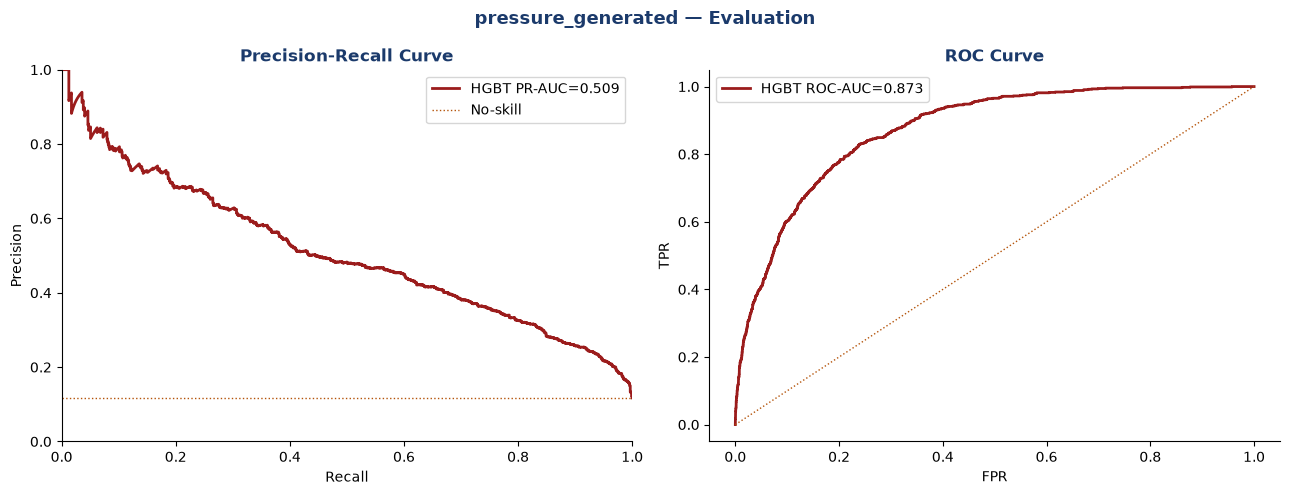

Optimal threshold : 0.500
                    precision    recall  f1-score   support

       No pressure       0.97      0.79      0.87      6543
Pressure generated       0.33      0.79      0.47       868

          accuracy                           0.79      7411
         macro avg       0.65      0.79      0.67      7411
      weighted avg       0.89      0.79      0.82      7411



In [35]:
thresh_range = np.linspace(0.01, 0.5, 200)
f1_scores    = [f1_score(y_test, (y_prob>=t).astype(int), zero_division=0) for t in thresh_range]
best_thresh  = thresh_range[np.argmax(f1_scores)]
best_f1      = max(f1_scores)
y_pred_opt   = (y_prob >= best_thresh).astype(int)

prec_h, rec_h, _ = precision_recall_curve(y_test, y_prob)
fpr_h, tpr_h, _  = roc_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(rec_h, prec_h, color=RED, lw=2, label=f"HGBT PR-AUC={pr_auc:.3f}")
axes[0].axhline(y_test.mean(), color=AMBER, ls=":", lw=1, label="No-skill")
axes[0].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve", xlim=[0,1], ylim=[0,1])
axes[0].legend()
axes[0].title.set(fontweight="bold", color=NAVY)

axes[1].plot(fpr_h, tpr_h, color=RED, lw=2, label=f"HGBT ROC-AUC={roc_auc:.3f}")
axes[1].plot([0,1],[0,1], color=AMBER, ls=":", lw=1)
axes[1].set(xlabel="FPR", ylabel="TPR", title="ROC Curve")
axes[1].legend()
axes[1].title.set(fontweight="bold", color=NAVY)

plt.suptitle("pressure_generated — Evaluation", fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

print(f"Optimal threshold : {best_thresh:.3f}")
print(classification_report(y_test, y_pred_opt, target_names=["No pressure", "Pressure generated"]))

##### Step 13: Feature Importance

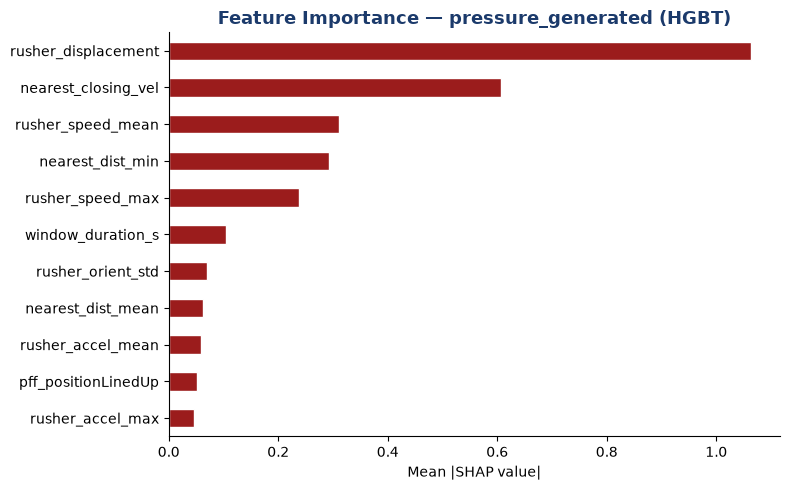

rusher_displacement    1.063219
nearest_closing_vel    0.607657
rusher_speed_mean      0.310236
nearest_dist_min       0.292295
rusher_speed_max       0.238441
window_duration_s      0.105036
rusher_orient_std      0.069944
nearest_dist_mean      0.063032
rusher_accel_mean      0.058850
pff_positionLinedUp    0.052222
rusher_accel_max       0.045832


In [ ]:
import shap
explainer = shap.TreeExplainer(hgbt)
shap_values = explainer.shap_values(X_test)
importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_COLS, name="importance"
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind="barh", ax=ax, color=RED, edgecolor="white")
ax.set_title("Feature Importance — pressure_generated (HGBT)",
             fontsize=13, fontweight="bold", color=NAVY)
ax.set_xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()
print(importance.sort_values(ascending=False).to_string())

##### Step 14: Position Analysis

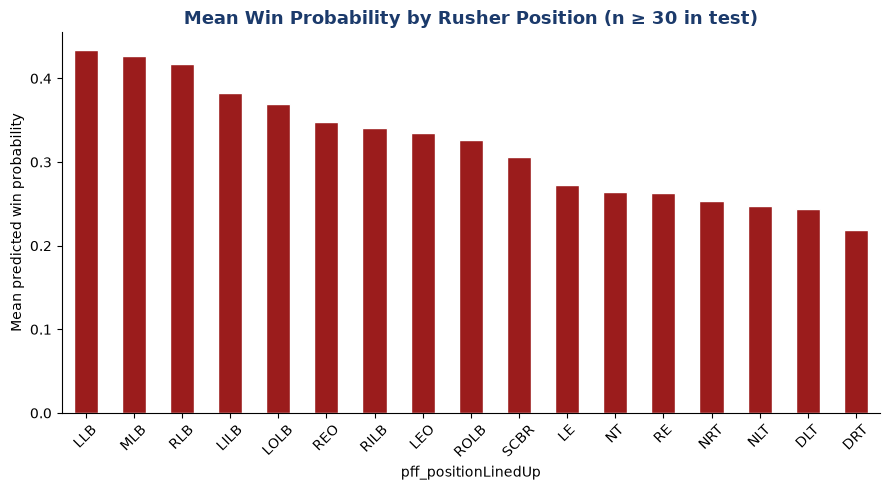

                         mean  count
pff_positionLinedUp                 
LLB                  0.433392     62
MLB                  0.426447     55
RLB                  0.417007     65
LILB                 0.382169    122
LOLB                 0.369569    788
REO                  0.347785    832
RILB                 0.341265    117
LEO                  0.334294    913
ROLB                 0.326017    829
SCBR                 0.305897     40
LE                   0.272526    658
NT                   0.263618    293
RE                   0.263393    457
NRT                  0.253198    115
NLT                  0.247716    120
DLT                  0.243787    851
DRT                  0.218384   1013


In [37]:
test_df = feature_table.iloc[test_idx].copy()
test_df["win_prob"] = y_prob
win_by_pos = (
    test_df.groupby("pff_positionLinedUp")["win_prob"]
    .agg(["mean", "count"])
    .query("count >= 30")
    .sort_values("mean", ascending=False)
)
fig, ax = plt.subplots(figsize=(9, 5))
win_by_pos["mean"].plot(kind="bar", ax=ax, color=RED, edgecolor="white")
ax.set_title("Mean Win Probability by Rusher Position (n ≥ 30 in test)",
             fontsize=13, fontweight="bold", color=NAVY)
ax.set_ylabel("Mean predicted win probability")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
print(win_by_pos.to_string())

##### Step 15: A vs B Comparison

In [38]:
# Load use case A metrics to compare
a_metrics_path = ROOT / "artifacts" / "pressure_allowed" / "metrics_report.json"
if a_metrics_path.exists():
    with open(a_metrics_path) as f:
        a_metrics = json.load(f)
    pr_auc_a = a_metrics["pr_auc"]
else:
    pr_auc_a = None
    print("Run notebook 03 first to get use case A metrics.")

comparison = pd.DataFrame([
    {"use case": "A: pressure_allowed",   "Side": "Offensive (blocker)",
     "Rows": f"{len(feature_table):,}",  "PR-AUC": str(pr_auc_a) if pr_auc_a else "run nb 03",
     "Key Feature": "separation_min, pff_positionLinedUp",
     "Business Use": "OL grading, protection design"},
    {"use case": "B: pressure_generated", "Side": "Defensive (rusher)",
     "Rows": f"{len(feature_table):,}",  "PR-AUC": f"{pr_auc:.4f}",
     "Key Feature": "nearest_dist_min, rusher_speed_max",
     "Business Use": "DL scouting, blitz design"},
])
print(comparison.to_string(index=False))

             use case                Side   Rows PR-AUC                         Key Feature                  Business Use
  A: pressure_allowed Offensive (blocker) 36,263 0.2945 separation_min, pff_positionLinedUp OL grading, protection design
B: pressure_generated  Defensive (rusher) 36,263 0.5089  nearest_dist_min, rusher_speed_max     DL scouting, blitz design


##### Step 16: Save & Summary

In [39]:
joblib.dump(hgbt,    ARTIFACT_DIR / "model.joblib")
joblib.dump(lr_pipe, ARTIFACT_DIR / "lr_model.joblib")
joblib.dump(enc_pos, ARTIFACT_DIR / "position_encoder.joblib")

feature_table.to_parquet(ARTIFACT_DIR / "feature_table.parquet", index=False)
pd.DataFrame({"feature": FEATURE_COLS,
              "importance": importance.reindex(FEATURE_COLS).values})\
  .sort_values("importance", ascending=False)\
  .to_csv(ARTIFACT_DIR / "feature_importance.csv", index=False)

# search.best_params_ holds numpy scalar types (from randint/uniform) — cast to
# native python so json.dump doesn't choke on them.
best_params_json = {k: (v.item() if hasattr(v, "item") else v)
                     for k, v in search.best_params_.items()}
metrics = {
    "pr_auc"          : round(float(pr_auc), 4),
    "roc_auc"         : round(float(roc_auc), 4),
    "lr_pr_auc"       : round(float(lr_pr_auc), 4),
    "baseline_pr_auc" : round(float(baseline_pr_auc), 4),
    "cv_score_mean"   : round(float(cv_score_mean), 4),
    "cv_score_std"    : round(float(cv_score_std), 4),
    "cv_scoring"      : "average_precision",
    "best_params"     : best_params_json,
    "best_threshold"  : round(float(best_thresh), 4),
    "best_f1"         : round(float(best_f1), 4),
    "n_train"         : int(len(X_train)),
    "n_test"          : int(len(X_test)),
    "positive_rate"   : round(float(y_test.mean()), 4),
    "key_design_note" : "nearest_dist_min replaces named opponent — handles double-teams",
}
with open(ARTIFACT_DIR / "metrics_report.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("═" * 58)
print(f"  Rows          : {len(feature_table):,} pass rush attempts")
print(f"  Positive rate : {pos/len(feature_table):.1%}")
print(f"  Baseline PR-AUC : {baseline_pr_auc:.4f}")
print(f"  LR PR-AUC       : {lr_pr_auc:.4f}")
print(f"  HGBT PR-AUC     : {pr_auc:.4f}")
print(f"  HGBT ROC-AUC    : {roc_auc:.4f}")
print("═" * 58)

══════════════════════════════════════════════════════════
  Rows          : 36,263 pass rush attempts
  Positive rate : 11.6%
  Baseline PR-AUC : 0.1177
  LR PR-AUC       : 0.3902
  HGBT PR-AUC     : 0.5089
  HGBT ROC-AUC    : 0.8731
══════════════════════════════════════════════════════════


<!-- CONCLUSION_CELL_11 -->